# Decision Tree (Деревья решений)

In [599]:
import os
import time
from collections import Counter
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit,
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder, TargetEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    mean_absolute_error, root_mean_squared_error, r2_score,
    make_scorer, mean_absolute_percentage_error, roc_auc_score
)
from graphviz import Source

import shap
import optuna

## Задание 1: Прогнозирование цен на недвижимость

### Описание:
Вы — аналитик в компании по недвижимости. Вам нужно построить модель, которая предсказывает стоимость квартиры на основе следующих признаков:

Площадь (кв. м)
Количество комнат
Район города
Этаж
Наличие балкона
Год постройки дома
Требования:

Постройте дерево решений с использованием алгоритма CART.
Визуализируйте дерево (например, с помощью graphviz или plot_tree из sklearn).
Оцените модель с помощью метрик: MAE, RMSE, R².
Проанализируйте, какие признаки наиболее значимы для предсказания цены.
Дополнительно:

Попробуйте ограничить глубину дерева и сравните результаты.
Обработайте категориальные признаки (например, район города).


#### Загрузка данных

In [600]:
dataset_dir_path = r"..\..\..\datasets\house_pricing"

train_data_path = os.path.join(dataset_dir_path, "train.json")
test_data_path = os.path.join(dataset_dir_path, "test.json")

train_df = pd.read_json(train_data_path)
test_df = pd.read_json(test_data_path)

train_df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [601]:
train_df.shape

(49352, 15)

#### Предобработка

In [602]:
train_df = train_df[(train_df['price'] > train_df['price'].quantile(0.01)) & (train_df['price'] < train_df['price'].quantile(0.99))]

train_df.shape

(48343, 15)

In [603]:
features = Counter(feature for row in pd.concat([train_df['features'], train_df['features']]) for feature in row)

mcfs = [feature[0] for feature in features.most_common(20)]
mcfs

['Elevator',
 'Hardwood Floors',
 'Cats Allowed',
 'Dogs Allowed',
 'Doorman',
 'Dishwasher',
 'No Fee',
 'Laundry in Building',
 'Fitness Center',
 'Pre-War',
 'Laundry in Unit',
 'Roof Deck',
 'Outdoor Space',
 'Dining Room',
 'High Speed Internet',
 'Balcony',
 'Swimming Pool',
 'Laundry In Building',
 'New Construction',
 'Terrace']

In [604]:
for feature in mcfs:
    train_df[feature] = train_df['features'].apply(lambda x: 1 if feature in x else 0)
    test_df[feature] = test_df['features'].apply(lambda x: 1 if feature in x else 0)

In [605]:
train_df.head(5)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level,Elevator,Hardwood Floors,Cats Allowed,Dogs Allowed,Doorman,Dishwasher,No Fee,Laundry in Building,Fitness Center,Pre-War,Laundry in Unit,Roof Deck,Outdoor Space,Dining Room,High Speed Internet,Balcony,Swimming Pool,Laundry In Building,New Construction,Terrace
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium,0,1,1,1,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium,1,1,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0


In [606]:
street_freq = train_df['street_address'].value_counts(normalize=True)

train_df['street_address_freq'] = train_df['street_address'].map(street_freq).fillna(0)
test_df['street_address_freq'] = test_df['street_address'].map(street_freq).fillna(0)

In [607]:
features = ['bathrooms', 'bedrooms', 'Balcony',
            'street_address_freq', 'latitude', 'longitude']

In [608]:
X_train = train_df.loc[:, features].copy()
y_train = train_df.loc[:, 'price'].copy()

X_val, X_test, y_val, y_test = train_test_split(test_df.loc[:, features], test_df.loc[:, 'price'], test_size=0.2, random_state=42)

In [609]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

#### Обучение

In [610]:
depths = [3, 5, 7, 10, None]
results = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=21)
    model.fit(X_train, y_train_log)
    pred = model.predict(X_val)
    results.append({
        'max_depth': depth,
        'MAE': mean_absolute_error(y_val_log, pred),
        'RMSE': root_mean_squared_error(y_val_log, pred),
        'R2': r2_score(y_val_log, pred)
    })

pd.DataFrame(results)

,max_depth,MAE,RMSE,R2
0,3.0,0.203812,0.279711,0.578705
1,5.0,0.177977,0.250279,0.662699
2,7.0,0.165368,0.237596,0.696020
3,10.0,0.149222,0.222795,0.732712
4,NaN,0.092001,0.186825,0.812052


In [611]:
dtr = DecisionTreeRegressor(max_depth=4)
dtr.fit(X_train, y_train_log)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

#### Оценка

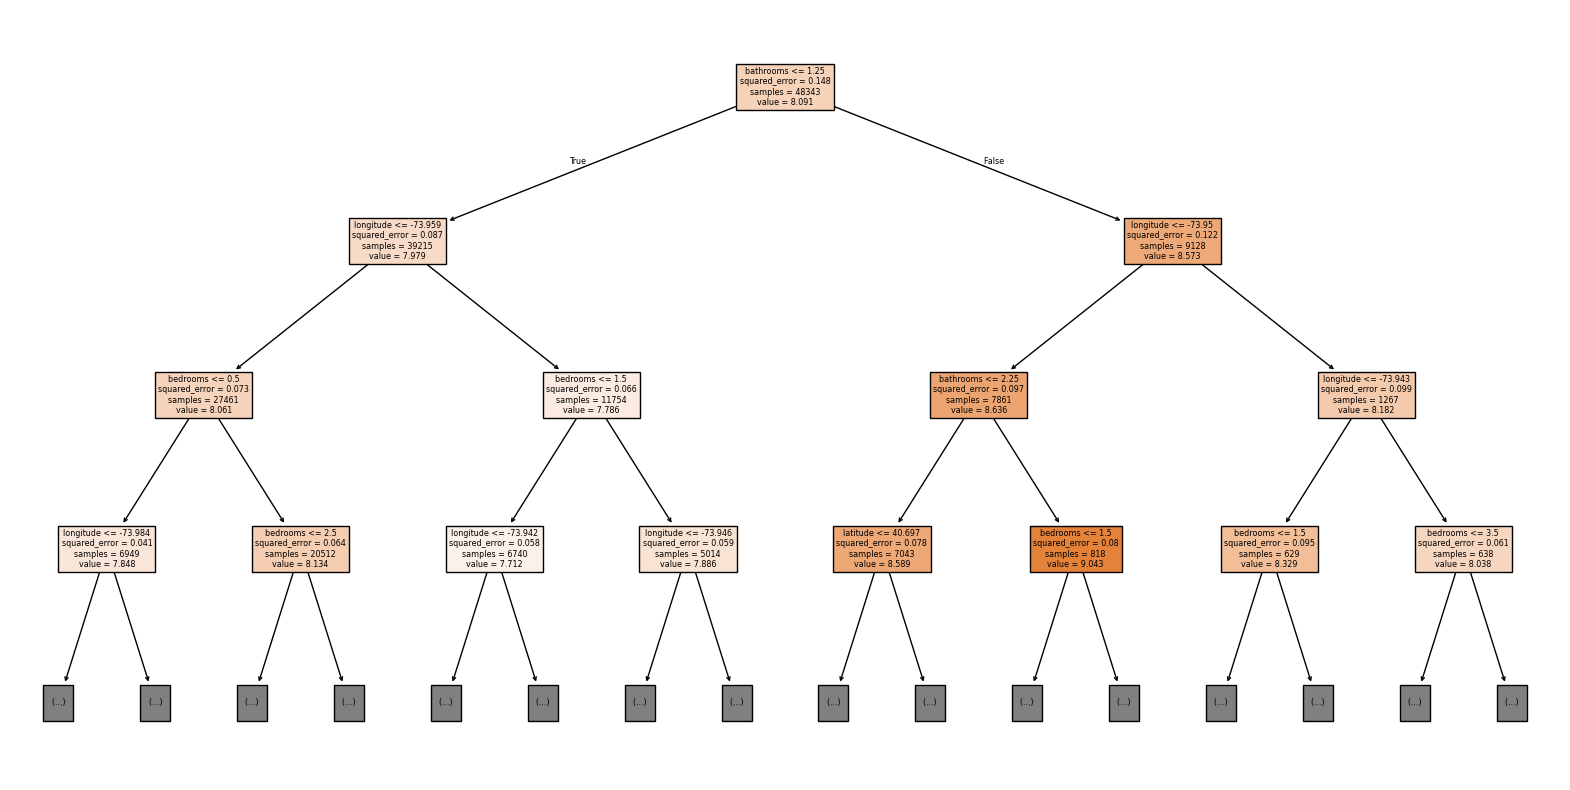

In [612]:
plt.figure(figsize=(20,10))
plot_tree(dtr, feature_names=dtr.feature_names_in_, max_depth=3, filled=True)
plt.show()

In [613]:
pred = dtr.predict(X_val)

metrics_res_df = pd.DataFrame({
    "MAE": [mean_absolute_error(y_val_log, pred)],
    "RMSE": [root_mean_squared_error(y_val_log, pred)],
    "R^2": [r2_score(y_val_log, pred)]
})

metrics_res_df

,MAE,RMSE,R^2
0,0.188436,0.262783,0.628153


In [614]:
importances_df = pd.DataFrame({
    "Feature name": dtr.feature_names_in_,
    "Importances": dtr.feature_importances_
})

importances_df

,Feature name,Importances
0,bathrooms,0.607925
1,bedrooms,0.154821
2,Balcony,0.000000
3,street_address_freq,0.000000
4,latitude,0.012310
5,longitude,0.224944


## Задание 2: Классификация клиентов банка

### Описание:
Банк хочет автоматизировать процесс одобрения кредитов. Вам нужно построить модель, которая классифицирует клиентов на "надёжных" и "ненадёжных" на основе:

Возраст
Доход
Кредитная история
Наличие ипотеки
Количество кредитов в прошлом
Требования:

Постройте дерево решений для классификации.
Оцените модель с помощью метрик: accuracy, precision, recall, F1-score.
Проанализируйте, какие признаки наиболее важны для принятия решения.
Визуализируйте дерево и интерпретируйте его.
Дополнительно:

Попробуйте использовать критерий Джини и энтропию для построения дерева. Сравните результаты.


#### Загрузка данных

In [615]:
dataset_dir_path = r"..\..\..\datasets\credit_borrowers"

data_path = os.path.join(dataset_dir_path, "bank.csv")

df = pd.read_csv(data_path, sep=';', header=0)

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [616]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [617]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [618]:
df.shape

(4521, 17)

#### Предобработка

In [619]:
numerical_features = df.select_dtypes('number')

numerical_features

,age,balance,day,duration,campaign,pdays,previous
0,30,1787,19,79,1,-1,0
1,33,4789,11,220,1,339,4
2,35,1350,16,185,1,330,1
3,30,1476,3,199,4,-1,0
4,59,0,5,226,1,-1,0
...,...,...,...,...,...,...,...
4516,33,-333,30,329,5,-1,0
4517,57,-3313,9,153,1,-1,0
4518,57,295,19,151,11,-1,0
4519,28,1137,6,129,4,211,3


In [620]:
categorical_features = df.select_dtypes('object')

categorical_features

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,unemployed,married,primary,no,no,no,cellular,oct,unknown,no
1,services,married,secondary,no,yes,yes,cellular,may,failure,no
2,management,single,tertiary,no,yes,no,cellular,apr,failure,no
3,management,married,tertiary,no,yes,yes,unknown,jun,unknown,no
4,blue-collar,married,secondary,no,yes,no,unknown,may,unknown,no
...,...,...,...,...,...,...,...,...,...,...
4516,services,married,secondary,no,yes,no,cellular,jul,unknown,no
4517,self-employed,married,tertiary,yes,yes,yes,unknown,may,unknown,no
4518,technician,married,secondary,no,no,no,cellular,aug,unknown,no
4519,blue-collar,married,secondary,no,no,no,cellular,feb,other,no


In [621]:
features = ['age', 'job', 'balance', 'default', 'housing', 'loan']
target = 'y'

In [622]:
X = df.loc[:, features].copy()
y = df.loc[:, target].copy()

In [623]:
y = y.map({'yes': 1, 'no': 0})

y.head()

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [624]:
def classify_features(X, features, threshold=0.05):
    valid_features_idx = (X.notna().sum() / len(X) > threshold).index.tolist()
    nunique = X[valid_features_idx].nunique()

    numerical_features = [col for col in valid_features_idx if X[col].dtype in ['int64', 'float64']]
    binary_features = [col for col in features if nunique[col] <= 2]
    small_categorical_features = [col for col in features if 3 <= nunique[col] <= 10]
    large_categorical_features = [col for col in features if nunique[col] > 10]

    return {
        'numerical_features': numerical_features,
        'binary_features': binary_features,
        'small_categorical_features': small_categorical_features,
        'large_categorical_features': large_categorical_features,
    }

In [625]:
cl_features = classify_features(X, features)

numerical_features = cl_features['numerical_features']
binary_features = cl_features['binary_features']
small_categorical_features = cl_features['small_categorical_features']
large_categorical_features = cl_features['large_categorical_features']

In [626]:
for feature in numerical_features:
    X[feature] = X[feature].fillna(X[feature].mean())

In [627]:
for feature in binary_features:
    X[feature] = X[feature].map({'yes': 1, 'no': 0}).fillna(0)

#### Разделение данных

In [628]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [629]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat_small', OneHotEncoder(handle_unknown='ignore', sparse_output=False), small_categorical_features),
    # ('cat_large', OrdinalEncoder(handle_unknown='use_encoded_value', encoded_missing_value=-1), large_categorical_features),
    ('binary', 'passthrough', binary_features)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

#### Обучение

In [630]:
dtc = DecisionTreeClassifier(max_depth=7)
dtc.fit(X_train_prep, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

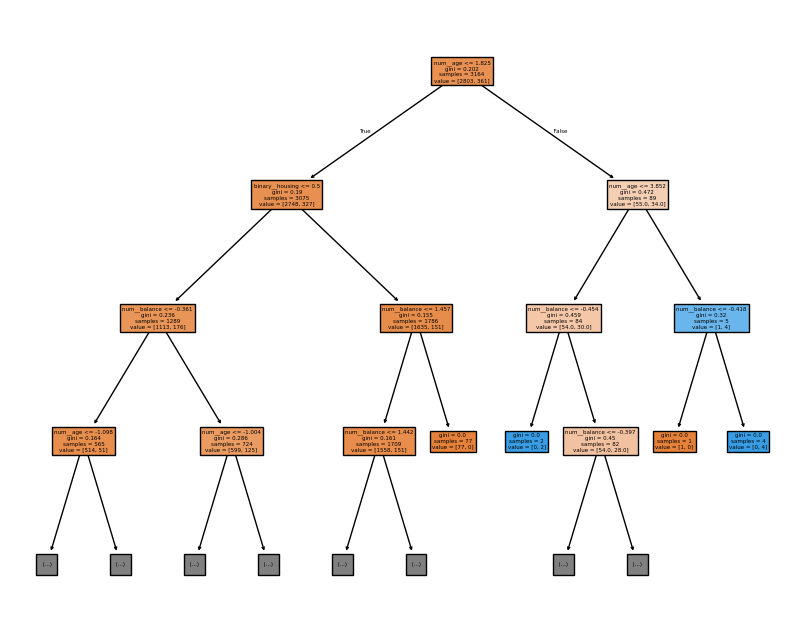

In [631]:
feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(10, 8))
plot_tree(dtc, feature_names=feature_names, max_depth=3, filled=True)
plt.show()

#### Оценка

In [632]:
y_pred = dtc.predict(X_test_prep)
y_pred_proba = dtc.predict_proba(X_test_prep)[:, 1]

In [633]:
eval_model_df = pd.DataFrame({
    'accuracy': [accuracy_score(y_test, y_pred)],
    'precision': [precision_score(y_test, y_pred)],
    'recall': [recall_score(y_test, y_pred)],
    'F1-score': [f1_score(y_test, y_pred)],
})

eval_model_df

,accuracy,precision,recall,F1-score
0,0.87325,0.3,0.05625,0.094737


In [634]:
gini = 2 * roc_auc_score(y_test, y_pred_proba) - 1

gini

0.21375313283208008

In [640]:
print("Распределение классов:")
print(y.value_counts(normalize=True))

Распределение классов:
y
0    0.88476
1    0.11524
Name: proportion, dtype: float64


In [635]:
models = {
    'Gini': DecisionTreeClassifier(criterion='gini', max_depth=15, class_weight='balanced', random_state=21),
    'Entropy': DecisionTreeClassifier(criterion='entropy', max_depth=15, class_weight='balanced', random_state=21)
}

In [636]:
results = {}
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]
    
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

In [637]:
results_df = pd.DataFrame(results).T.round(4)
print("✅ Сравнение Gini vs Entropy:")
print(results_df)

✅ Сравнение Gini vs Entropy:
         accuracy  precision  recall      f1  roc_auc
Gini       0.7170     0.1291  0.2438  0.1688   0.4980
Entropy    0.6094     0.1130  0.3375  0.1693   0.5034


In [638]:
feature_names_out = preprocessor.get_feature_names_out()

print("\n✅ Важность фичей (Gini):")
importance = pd.DataFrame({
    'feature': feature_names_out,
    'importance': models['Gini'].feature_importances_
}).sort_values('importance', ascending=False)
print(importance)


✅ Важность фичей (Gini):
           feature  importance
1     num__balance    0.599721
0         num__age    0.315047
3  binary__housing    0.038258
4     binary__loan    0.034577
2  binary__default    0.012398


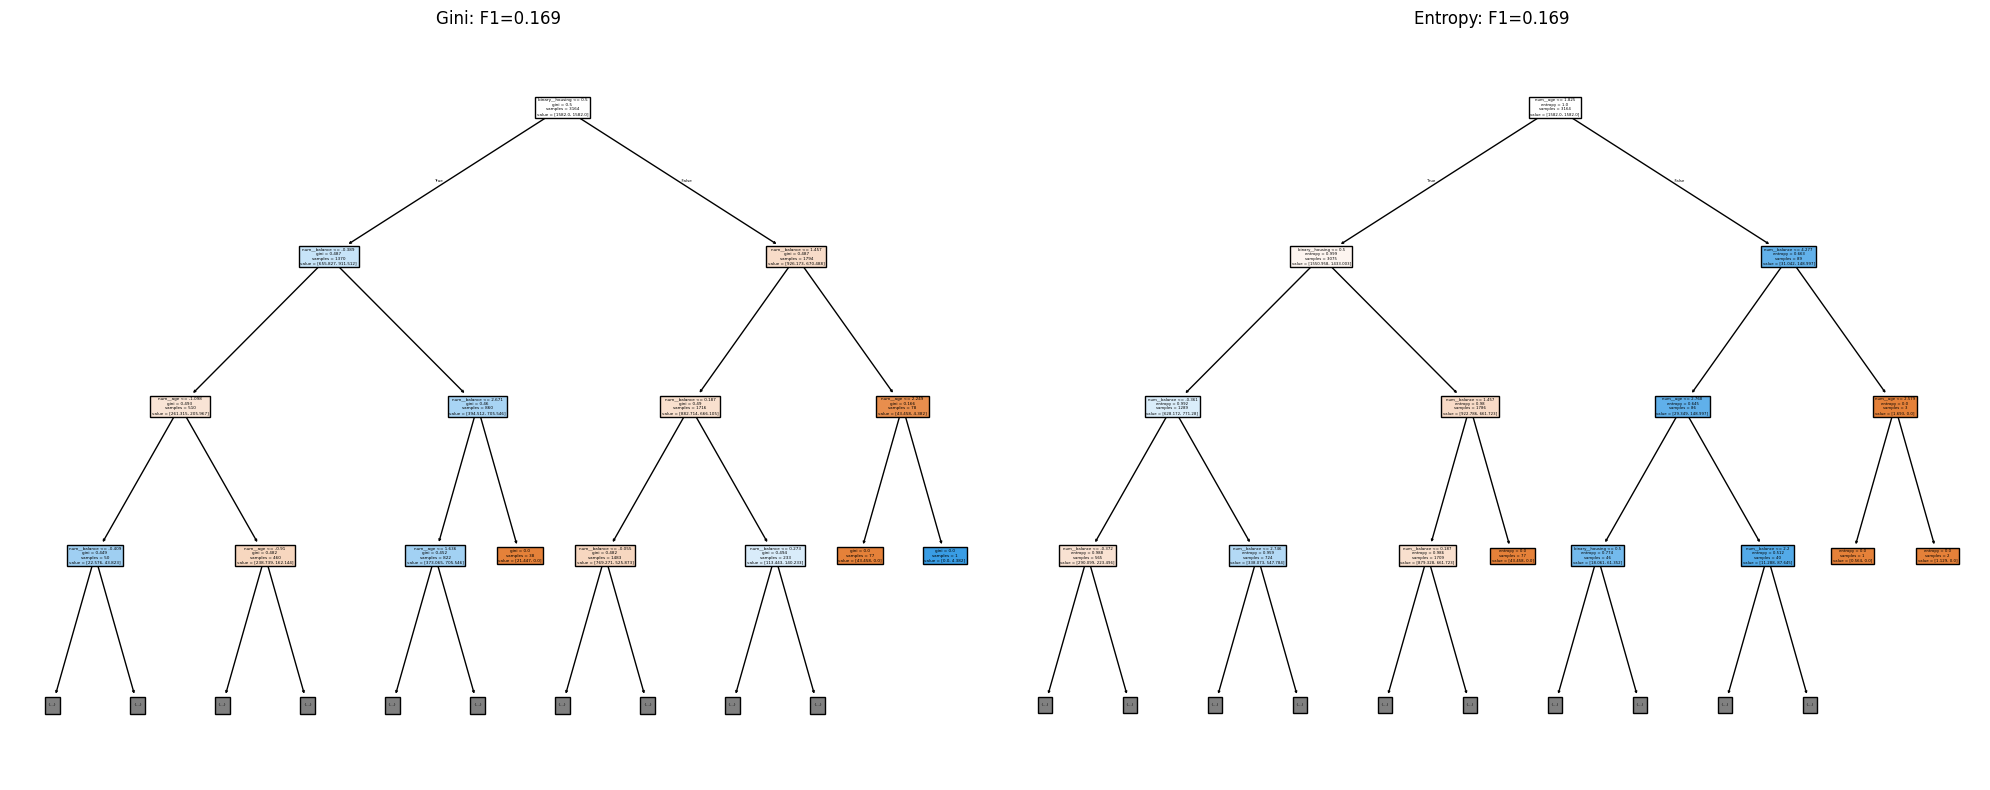

In [639]:
feature_names = preprocessor.get_feature_names_out()
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for i, (name, model) in enumerate(models.items()):
    plot_tree(model, feature_names=feature_names, max_depth=3, 
              filled=True, ax=axes[i])
    axes[i].set_title(f'{name}: F1={results[name]["f1"]:.3f}')
plt.tight_layout()
plt.show()

CV F1: 0.178 ± 0.050


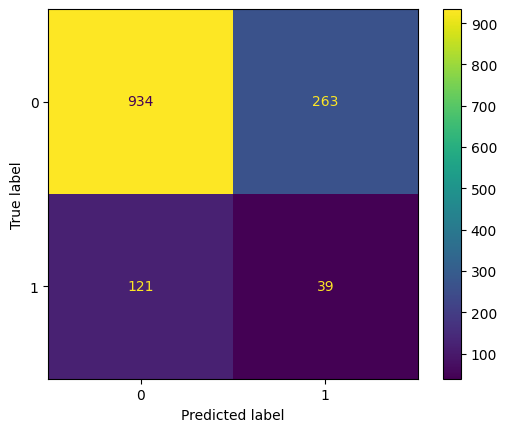

In [642]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(models['Gini'], X_train_prep, y_train, 
                        cv=5, scoring='f1')
print(f"CV F1: {scores.mean():.3f} ± {scores.std():.3f}")

# 2. Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, models['Gini'].predict(X_test_prep))
ConfusionMatrixDisplay(cm).plot()
plt.show()